# Clasificación Predictiva en Enfermedad de Alzheimer

<img src="https://cdn-icons-png.flaticon.com/512/5635/5635722.png" width="200">

Autor: **Javier Gonzalez Sanabria**, PhD.

Role target: Data Scientist, Jr.

Proyecto de Machine Learning aplicado a Healthcare / Life Sciences (Proyecto formativo y de portfolio personal)

Objetivo: desarrollar un modelo de clasificación interpretable como ejercicio aplicado de formación en Data Science, orientado a simular un escenario realista de priorización clínica de pacientes con riesgo de enfermedad de Alzheimer. El foco del análisis está puesto en la claridad conceptual, la correcta formulación del problema, la interpretabilidad del modelo y la adopción de buenas prácticas reproducibles, más que en la optimización extrema del rendimiento predictivo.

## 0. Setup y contexto del proyecto

### 0.1 Librerías y configuración del entorno

En este proyecto se utilizarán librerías estándar del ecosistema Python para análisis de datos y Machine Learning, priorizando herramientas ampliamente adoptadas en entornos profesionales y clínicos.

- Manipulación de datos: **pandas, numpy**

- Visualización: **matplotlib, seaborn**

- Machine Learning: **scikit-learn**

### 0.2 Reproducibilidad

Dado que el proyecto tiene un objetivo formativo y de portfolio, se establece una **semilla aleatoria fija** para garantizar que los resultados obtenidos puedan ser reproducidos.

### 0.3 Contexto clínico y objetivo del modelo

- Problema clínico

  La enfermedad de Alzheimer representa la principal causa de deterioro cognitivo (demencia) en adultos mayores a nivel mundial. En contextos clínicos reales, la detección temprana y la correcta priorización de pacientes para evaluaciones especializadas constituyen un desafío relevante, especialmente cuando los recursos diagnósticos son limitados.

  Este proyecto plantea un escenario simplificado en el que se dispone de información demográfica, clínica, funcional y cognitiva de pacientes, con el objetivo de estimar la **probabilidad de diagnóstico de enfermedad de Alzheimer**.

- Rol del modelo

  El modelo desarrollado en este notebook no tiene como finalidad realizar un diagnóstico clínico, sino funcionar como una herramienta de decision support.
  Tiene como proposito poder apoyar la priorización de pacientes con mayor riesgo. Además, busca ilustrar cómo modelos de Machine Learning pueden integrarse como soporte a la toma de decisiones clínicas.
  Nota importante: El modelo no reemplaza la evaluación médica ni las pruebas diagnósticas formales.

- Alcance y limitaciones

  Este análisis se basa en un dataset secundario de origen público (Kaggle), sin validación externa. Los resultados no son generalizables a poblaciones reales sin un proceso formal de validación clínica.
  El foco de este proyecto está en la metodología, interpretabilidad y narrativa técnica, no en la optimización extrema del rendimiento predictivo.

## 1. Descripción del dataset

### 1.1 Origen del dataset

El dataset utilizado en este proyecto corresponde al Alzheimer’s Disease Dataset, publicado por *Rabie El Kharoua* en Kaggle (2024).

Se trata de un conjunto de datos sintético/curado con fines educativos, que simula información clínica y demográfica de pacientes evaluados por posible enfermedad de Alzheimer.

El uso de este tipo de datasets es habitual en contextos formativos, ya que permite trabajar con variables clínicamente plausibles sin implicar datos sensibles reales.

### 1.2 Descripción general de las variables

El dataset incluye variables que pueden agruparse en las siguientes categorías conceptuales:

- Factores demográficos: Variables como edad y sexo, que actúan como moduladores de riesgo y contexto clínico.

- Estilo de vida: Información relacionada con hábitos que pueden influir indirectamente en la salud cognitiva.

- Historia médica: Variables asociadas a antecedentes clínicos relevantes, particularmente aquellos vinculados a riesgo cardiovascular y metabólico.

- Mediciones clínicas: Incluyen parámetros como BMI, presión arterial y colesterol, utilizados como indicadores de estado general de salud.

- Evaluaciones cognitivas y funcionales: Puntajes derivados de pruebas estandarizadas (por ejemplo, MMSE y evaluaciones funcionales), que reflejan de manera directa el estado cognitivo y la capacidad funcional del paciente.

Desde una perspectiva clínica, este último grupo constituye el núcleo informativo más cercano al fenotipo de la enfermedad.

### 1.3 Variable objetivo

La variable objetivo del análisis es **Diagnosis**, una variable binaria que indica la presencia (1) o ausencia (0) de diagnóstico de enfermedad de Alzheimer.

En el contexto de este proyecto, esta variable se interpreta como un label para tareas de clasificación supervisada, y no como un diagnóstico clínico definitivo.

### 1.4 Supuestos y advertencias clínicas

Tener en cuenta para evitar extrapolaciones inapropiadas y para mantener una comunicación responsable en contextos de salud, que:

- El dataset no representa una cohorte clínica real ni un estudio epidemiológico validado.

- Las relaciones entre variables pueden no reflejar completamente la complejidad biológica y clínica de la enfermedad de Alzheimer.

- Los resultados obtenidos deben interpretarse exclusivamente en el marco de un ejercicio formativo.

## 2. Carga de datos y exploración inicial

### 2.1 Carga del dataset

In [2]:
import pandas as pd

# Ruta local al archivo CSV
data_path = "/content/alzheimers_disease_data.csv"

# Carga del dataset
df = pd.read_csv(data_path)

# Inspección inicial
df.head(20)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
5,4756,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,...,0,0,9.015686,1,0,0,0,0,0,XXXConfid
6,4757,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,...,0,0,9.236328,0,0,0,0,1,0,XXXConfid
7,4758,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,...,0,0,4.517248,1,0,0,0,1,1,XXXConfid
8,4759,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,...,0,1,0.756232,0,0,1,0,0,0,XXXConfid
9,4760,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,...,0,1,4.554394,0,0,0,0,0,0,XXXConfid


### 2.2 Dimensiones y tipos de datos

In [3]:
# Dimensiones del dataset
print(f"Número de observaciones: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

# Información general del dataset
df.info()

Número de observaciones: 2149
Número de variables: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  

### 2.3 Valores faltantes

In [4]:
# Cantidad de valores faltantes por variable
missing_counts = df.isna().sum()

# Porcentaje de valores faltantes por variable
missing_percentage = (missing_counts / len(df)) * 100

# Resumen en un DataFrame
missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_percentage
}).sort_values(by="missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
PatientID,0,0.0
Age,0,0.0
Gender,0,0.0
Ethnicity,0,0.0
EducationLevel,0,0.0
BMI,0,0.0
Smoking,0,0.0
AlcoholConsumption,0,0.0
PhysicalActivity,0,0.0
DietQuality,0,0.0


### 2.4 Distribución del target

En este trabajo apuntamos a Diagnostico como variable target. Es necesario evaluar posible desbalance de clases ya que puede sesgar métricas de performance del modelo.

In [5]:
# Conteo absoluto de clases
target_counts = df["Diagnosis"].value_counts().sort_index()

# Porcentaje por clase
target_percentage = df["Diagnosis"].value_counts(normalize=True).sort_index() * 100

# Resumen en DataFrame
target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentage
})

target_distribution

,count,percentage
Diagnosis,,
0,1389,64.634714
1,760,35.365286


La variable *target* presenta un desbalance moderado, **2/3 : 1/3** respecto del diagnostico **negativo : positivo**. Esto es consistente con escenarios de screening clínico en Alzheimer. Por esto, vamos a priorizar métricas robustas al desbalance y evaluaremos el desempeño del modelo más allá del *accuracy*, evitando técnicas de balanceo artificial en etapas tempranas.

## 3. EDA orientado a clínica

En esta sección realizaremos un análisis exploratorio de las variables clínicas con mayor poder discriminatorio para el diagnóstico de Alzheimer. Al ser una patología caracterizada por el deterioro progresivo, es fundamental evaluar la relación entre la **edad** y el **rendimiento en pruebas estandarizadas**.

Nos centraremos en tres dimensiones críticas: el MMSE (Mini-Mental State Examination) como medida de estado cognitivo global, el Functional Assessment para evaluar el desempeño en tareas complejas, y el ADL (Activities of Daily Living) como indicador de autonomía funcional. Estas variables, al presentarse como escalas numéricas, permiten observar gradientes de deterioro que variables tabulares binarias (como Memory Complaints o Behavioral Problems) no logran capturar con la misma resolución estadística."

### 3.1 Variables cognitivas y funcionales vs diagnóstico


In [6]:
# Exploramos variables cognitivas y funcionales
variables_cognitivas = ["MMSE", "FunctionalAssessment", "MemoryComplaints", "BehavioralProblems", "ADL"]

df[variables_cognitivas].describe()

,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,14.755132,5.080055,0.208004,0.156817,4.982958
std,8.613151,2.892743,0.405974,0.363713,2.949775
min,0.005312,0.000460,0.000000,0.000000,0.001288
25%,7.167602,2.566281,0.000000,0.000000,2.342836
50%,14.441660,5.094439,0.000000,0.000000,5.038973
75%,22.161028,7.546981,0.000000,0.000000,7.581490
max,29.991381,9.996467,1.000000,1.000000,9.999747


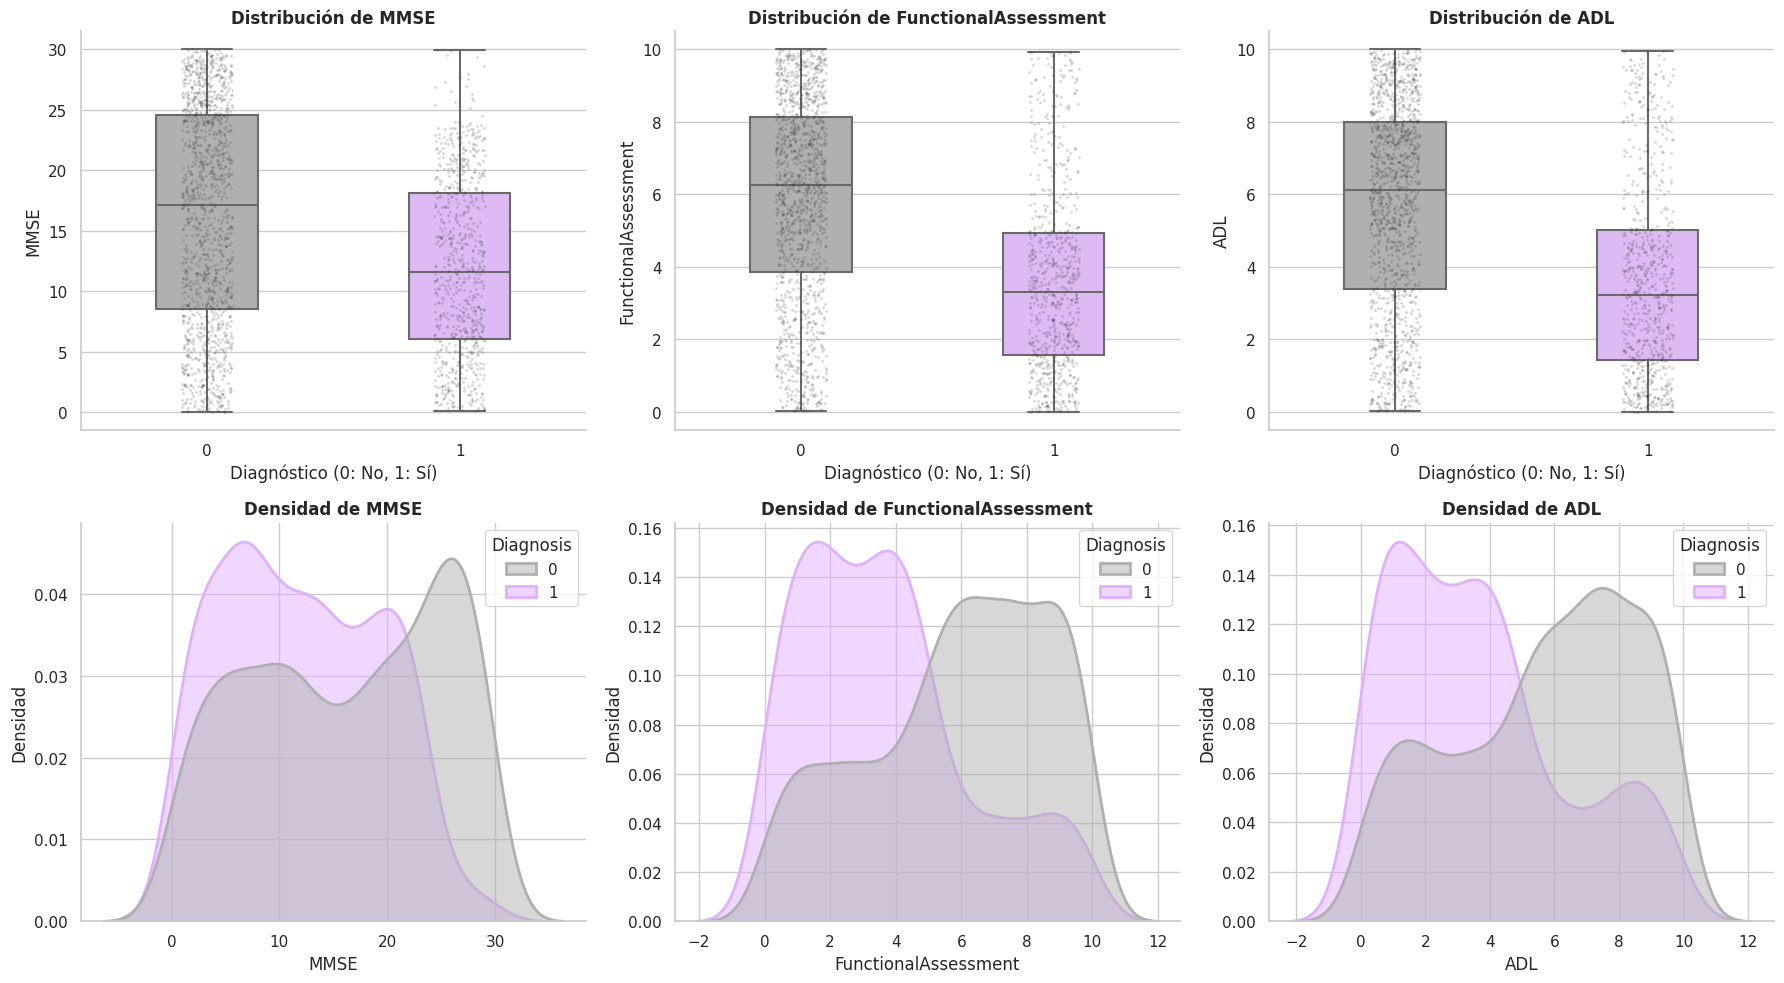

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

cognitive_features = ["MMSE", "FunctionalAssessment", "ADL"]

# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
palette_colors = {0: "#B0B0B0", 1: "#E0B0FF"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, feature in enumerate(cognitive_features):
    # Boxplots
    sns.boxplot(
        data=df,
        x='Diagnosis',
        y=feature,
        hue='Diagnosis',
        palette=palette_colors,
        linewidth=1.5,
        fliersize=0,
        width=0.4,
        dodge=False,
        ax=axes_flat[i]
    )
    sns.stripplot(
        data=df, x='Diagnosis', y=feature,
        color=".2", alpha=0.2, size=2, jitter=True, ax=axes_flat[i]
    )
    axes_flat[i].set_title(f"Distribución de {feature}", fontsize=12, fontweight='bold')

    # Manejo de leyenda para el boxplot
    if axes_flat[i].get_legend():
        axes_flat[i].get_legend().remove()

    # KDE Plots
    sns.kdeplot(
        data=df,
        x=feature,
        hue="Diagnosis",
        palette=palette_colors,
        common_norm=False,
        fill=True,
        alpha=0.5,
        linewidth=2,
        ax=axes_flat[i+3]
    )
    axes_flat[i+3].set_title(f"Densidad de {feature}", fontsize=12, fontweight='bold')

# Mejora de etiquetas y limpieza
for n, ax in enumerate(axes_flat):
    # Etiquetas de X solo para la fila de abajo o según el tipo de gráfico
    if n < 3:
        ax.set_xlabel("Diagnóstico (0: No, 1: Sí)")
    else:
        ax.set_xlabel(cognitive_features[n-3])
        ax.set_ylabel("Densidad")

sns.despine()
plt.tight_layout()
plt.show()

### 3.2 Edad vs diagnóstico

En el Alzheimer es esperable que a mayor Edad los pacientes muestren un mayor grado de deterioro cognitivo. Pero esta variable puede ser considerada como factor de riesgo para es diagnostico pero con poco poder predictivo para nuestro modelo.

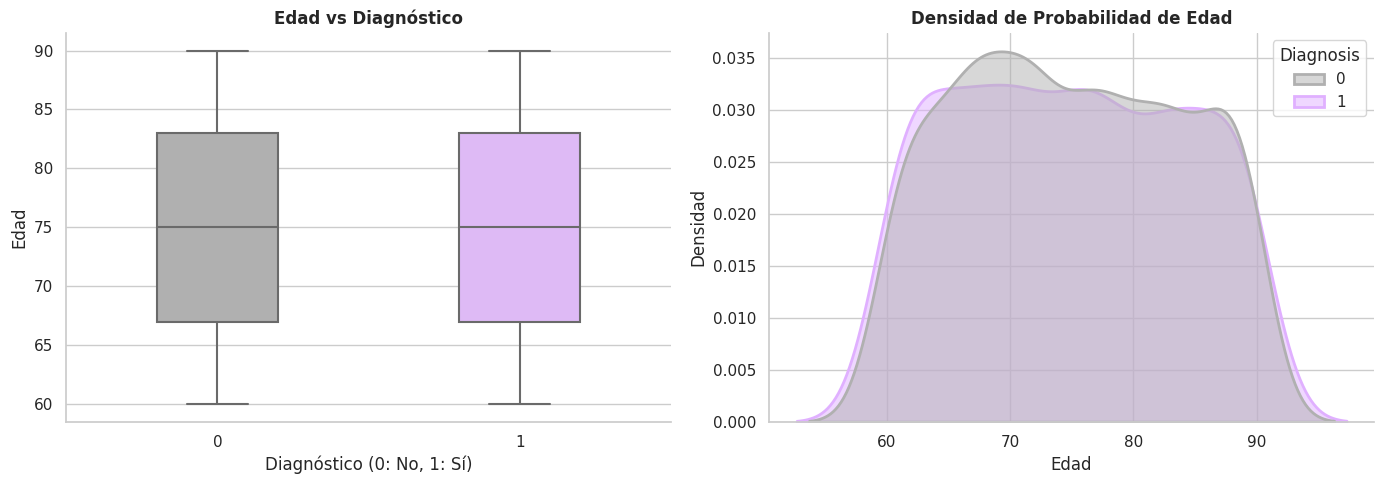

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplots
sns.boxplot(
    data=df,
    x='Diagnosis',
    y='Age',
    hue='Diagnosis',
    palette=palette_colors,
    linewidth=1.5,
    fliersize=4,
    width=0.4,
    dodge=False,
    ax=axes[0]  # Indicamos que vaya al primer espacio
)

axes[0].set_title('Edad vs Diagnóstico', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Diagnóstico (0: No, 1: Sí)')
axes[0].set_ylabel('Edad')
axes[0].get_legend().remove() # Removemos leyenda repetitiva

# KDE plots
sns.kdeplot(
    data=df,
    x="Age",
    hue="Diagnosis",
    palette=palette_colors,
    common_norm=False,
    fill=True,
    alpha=0.5,
    linewidth=2,
    ax=axes[1]  # segundo espacio
)
axes[1].set_title('Densidad de Probabilidad de Edad', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Densidad')

sns.despine()
plt.tight_layout()
plt.show()


Podemos ver que la edad por si sola no presenta un umbral etario que separe los grupos de diagnostico. Es posible decir que el riesgo aumenta con la edad a nivel poblacional, pero no es predictivo a nivel individual. Esta variable no la vamos a descartar sino que vamos a considerarla pero no como un feature dominante en la pedicción del modelo diagnostico.

### 3.3 Variables clínicas y de estilo de vida

Las variables clínicas y de estilo de vida son clave en Alzheimer porque son factores de riesgo modificables que promueven la patología β-amiloide y vascular, permiten predecir el riesgo años antes y orientan intervenciones para retrasar o prevenir hasta un 45% de casos.

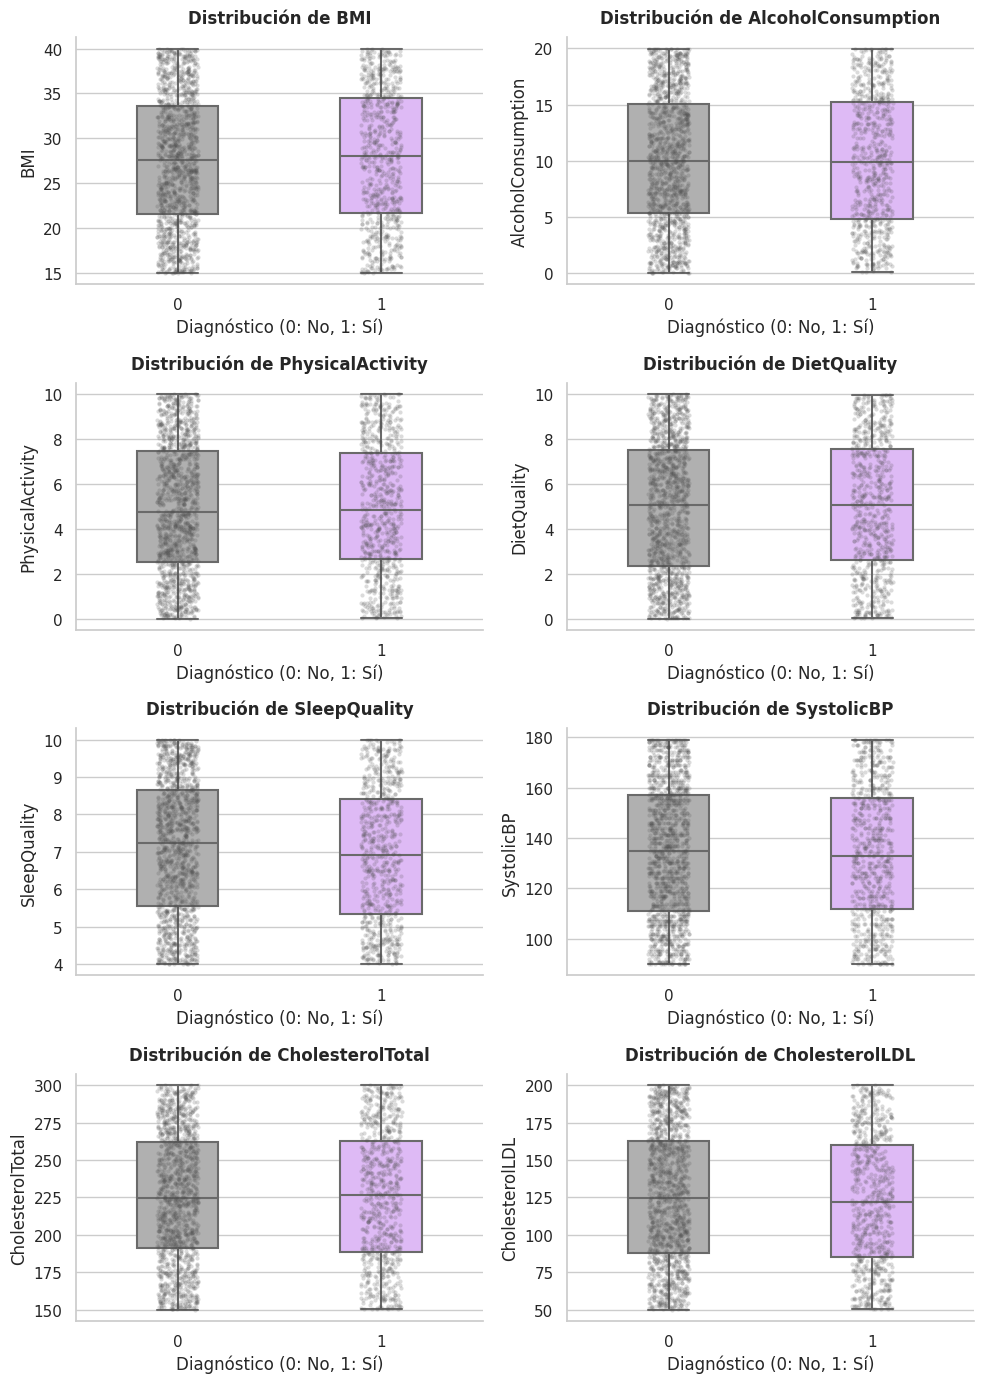

In [9]:
clinical_vars = [
    "BMI", "AlcoholConsumption", "PhysicalActivity",
    "DietQuality", "SleepQuality", "SystolicBP",
    "CholesterolTotal", "CholesterolLDL"
]

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes_flat = axes.flatten()

palette_colors = {0: "#B0B0B0", 1: "#E0B0FF"}

for i, var in enumerate(clinical_vars):
    # Boxplots
    sns.boxplot(
        data=df,
        x="Diagnosis",
        y=var,
        hue="Diagnosis",
        palette=palette_colors,
        linewidth=1.5,
        fliersize=0,      # Puntos reales gestionados por stripplot
        width=0.4,
        dodge=False,
        ax=axes_flat[i]
    )

    # Stripplot
    sns.stripplot(
        data=df,
        x="Diagnosis",
        y=var,
        color=".3",       # Gris oscuro neutro
        alpha=0.2,        # Transparencia para notar la densidad
        size=3,
        jitter=True,
        ax=axes_flat[i]
    )

    # Personalización de títulos y etiquetas
    axes_flat[i].set_title(f"Distribución de {var}", fontsize=12, fontweight='bold', pad=10)
    axes_flat[i].set_xlabel("Diagnóstico (0: No, 1: Sí)")
    axes_flat[i].set_ylabel(var)

    # Limpieza de leyendas redundantes
    if axes_flat[i].get_legend():
        axes_flat[i].get_legend().remove()

# Ajustes de diseño final
sns.despine()
plt.tight_layout()
plt.show()

En nuestro dataset podemos ver que las variables clínicas y de estilo de vida no muestran una separación clara entre grupos diagnósticos cuando se consideran de forma aislada. Sin embargo, se mantendrán en el modelo como posibles moduladores de riesgo, evaluando su contribución mediante regularización y análisis de importancia de variables.

### 3.4 Análisis de variables binarias (antecedentes médicos y sintomatología cognitiva/conductual)

Definimos una funcion auxiliar para poder evaluar cual es la prevalencia de las metricas respecto del diagnostico de Alzheimer:

In [10]:
def binary_proportion_summary(df, variables, target="Diagnosis"):
    # Calculamos la media y la expresamos en %
    summary = (
        df.groupby(target)[variables]
        .mean()
        .T * 100
    )

    summary = summary.reset_index()
    summary.columns = ["Variable", "% en Diag. Negativo", "% en Diag. Positivo"]

    # Diff %
    summary['Dif_Absoluta'] = (summary["% en Diag. Positivo"] - summary["% en Diag. Negativo"]).round(2)

    return summary.sort_values(by="Dif_Absoluta", ascending=False)

#### 3.4.1 Antecedentes médicos

In [11]:
medical_history_vars = [
    "FamilyHistoryAlzheimers",
    "CardiovascularDisease",
    "Diabetes",
    "Depression"
]

medical_history_summary = binary_proportion_summary(df, medical_history_vars)
display(medical_history_summary.style.format(precision=2).background_gradient(subset=['Dif_Absoluta'], cmap='Purples'))


,Variable,% en Diag. Negativo,% en Diag. Positivo,Dif_Absoluta
1,CardiovascularDisease,13.61,15.92,2.31
3,Depression,20.23,19.74,-0.49
2,Diabetes,15.91,13.55,-2.36
0,FamilyHistoryAlzheimers,26.28,23.29,-2.99


La tabla muestra la prevalencia de antecedentes por grupo diagnóstico. Los pacientes con Alzheimer exhiben +2,31 % más enfermedades cardiovasculares (coherente con el rol vascular en la patología). Sorprendentemente, el grupo sin diagnóstico presenta mayor prevalencia de antecedentes familiares de Alzheimer, resultado contraintuitivo que podría deberse a **sesgos en los datos** (subdiagnóstico, sesgo de selección o mayor vigilancia en familias afectadas).

#### 3.4.2 Sintomatología cognitiva y conductual

In [12]:
symptom_vars = [
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness",
    "MemoryComplaints",
    "BehavioralProblems"
]

symptom_vars_summary = binary_proportion_summary(df, symptom_vars)
display(symptom_vars_summary.style.format(precision=2).background_gradient(subset=['Dif_Absoluta'], cmap='Purples'))

,Variable,% en Diag. Negativo,% en Diag. Positivo,Dif_Absoluta
5,MemoryComplaints,11.59,37.63,26.04
6,BehavioralProblems,9.65,26.71,17.06
3,DifficultyCompletingTasks,15.62,16.32,0.69
4,Forgetfulness,30.17,30.13,-0.03
2,PersonalityChanges,15.62,14.08,-1.54
0,Confusion,21.09,19.47,-1.62
1,Disorientation,16.49,14.61,-1.88


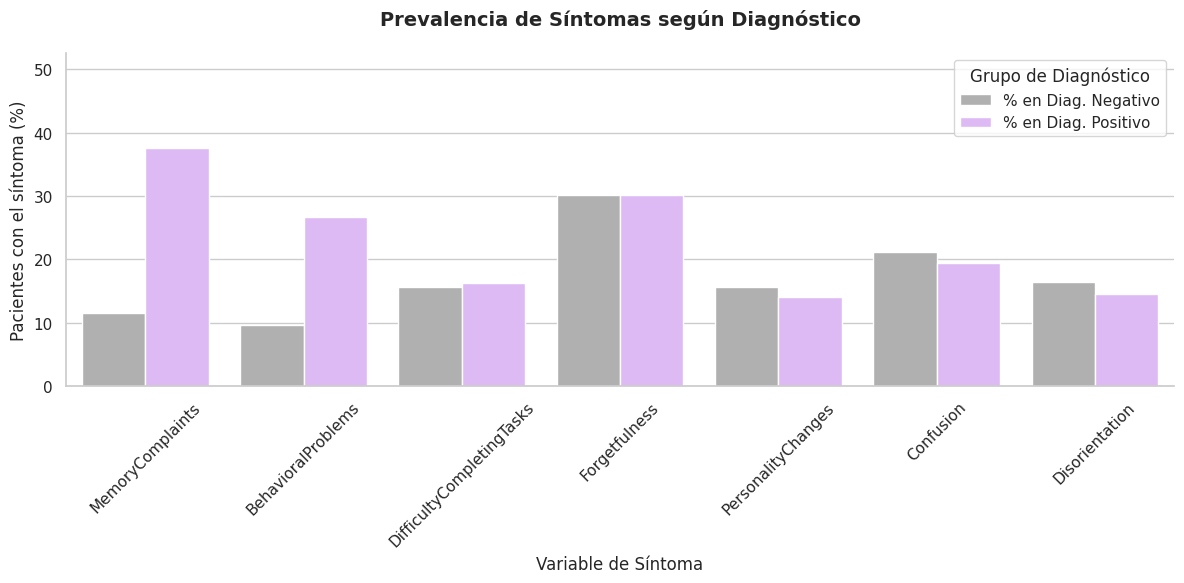

In [13]:
resumen_plot = symptom_vars_summary.melt(
    id_vars="Variable",
    value_vars=["% en Diag. Negativo", "% en Diag. Positivo"],
    var_name="Grupo",
    value_name="Porcentaje"
)

palette_sintomas = {
    "% en Diag. Negativo": "#B0B0B0",  # Gris
    "% en Diag. Positivo": "#E0B0FF"   # Violeta claro
}

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=resumen_plot,
    x="Variable",
    y="Porcentaje",
    hue="Grupo",
    palette=palette_sintomas
)

plt.title("Prevalencia de Síntomas según Diagnóstico", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Pacientes con el síntoma (%)")
plt.xlabel("Variable de Síntoma")
plt.xticks(rotation=45)
plt.ylim(0, resumen_plot["Porcentaje"].max() + 15)
plt.legend(title="Grupo de Diagnóstico", loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()

Contrario a la expectativa clínica, síntomas cardinales como Confusion y Disorientation presentan una prevalencia ligeramente mayor en el grupo sin diagnóstico. Esta inversión de la tendencia sugiere que, en este dataset, estos síntomas actúan como fuentes de ruido, posiblemente por solapamiento con otras condiciones (depresión, delirium o deterioro cognitivo leve no progresivo).

En contraste, otras variables sí exhiben separaciones claras y clínicamente relevantes. Tanto las quejas subjetivas de memoria (**MemoryComplaints**) como los problemas conductuales (**BehavioralProblems**) muestran diferencias absolutas significativas a favor del grupo positivo, alineándose con la literatura que asocia estos dominios al deterioro en Alzheimer (alteraciones conductuales como agitación, apatía, irritabilidad o síntomas neuropsiquiátricos aparecen frecuentemente en etapas moderadas-avanzadas).

### 3.5 Correlaciones y redundancia entre variables

Dado el resultado previo (síntomas binarios con comportamiento ruidoso), esta sección no busca descubrir señal nueva, sino detectar redundancia, colinealidad y proxies clínicos antes del modelado.

#### 3.5.1 Correlaciones entre métricas cognitivas y funcionales

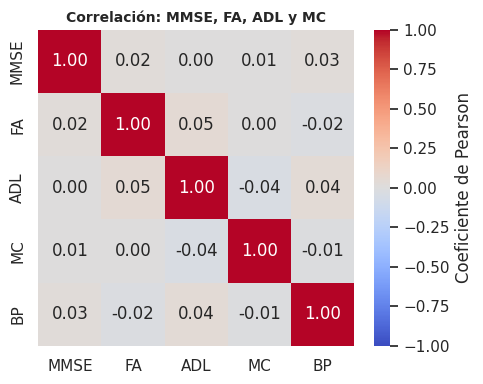

In [14]:
cognitive_vars = ["MMSE", "FunctionalAssessment", "ADL", "MemoryComplaints", "BehavioralProblems"]
corr_cognitive = df[cognitive_vars].corr()

short_names = {
    "MMSE": "MMSE",
    "FunctionalAssessment": "FA",
    "ADL": "ADL",
    "MemoryComplaints": "MC",
    "BehavioralProblems": "BP"
}

corr_visual = corr_cognitive.rename(columns=short_names, index=short_names)

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_visual,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Coeficiente de Pearson'}
)

plt.title("Correlación: MMSE, FA, ADL y MC", fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

La matriz de correlación revela una independencia casi absoluta entre estas variables: $r < abs(0.05$). Desde un punto de vista analítico, esto es altamente positivo para el modelado, ya que garantiza la ausencia de multicolinealidad. Sin embargo, desde una perspectiva clínica, es un hallazgo atípico que sugiere que el deterioro en este grupo de datos no sigue un patrón lineal uniforme entre cognición y funcionalidad.

#### 3.5.2 Correlaciones dentro de mediciones clínicas

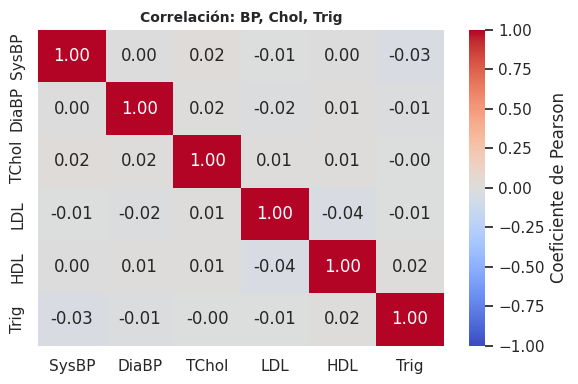

In [15]:
clinical_measurements = [
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides"
]

corr_clinical = df[clinical_measurements].corr()

short_names = {
    "SystolicBP": "SysBP",
    "DiastolicBP": "DiaBP",
    "CholesterolTotal": "TChol",
    "CholesterolLDL": "LDL",
    "CholesterolHDL": "HDL",
    "CholesterolTriglycerides": "Trig"
}

corr_visual = corr_clinical.rename(columns=short_names, index=short_names)

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_visual,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Coeficiente de Pearson'}
)

plt.title("Correlación: BP, Chol, Trig", fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

El análisis de correlaciones entre predictores muestra relaciones mayormente débiles, sin evidencia de multicolinealidad significativa. Esto sugiere que las variables aportan información complementaria y que no es necesario realizar una selección agresiva de features en esta etapa. En consecuencia, se optará por estrategias de modelado que permitan manejar posibles interacciones entre variables, evaluando tanto enfoques lineales interpretables como modelos más flexibles, comparando su desempeño de forma empírica.


## 4. Preparación de datos

A partir del EDA se identificaron variables con alto poder discriminante, en particular las métricas funcionales y cognitivas validadas (MMSE, ADL, FunctionalAssessment), así como algunas variables binarias asociadas a dominios clínicamente relevantes, como las quejas subjetivas de memoria (MemoryComplaints) y los problemas conductuales (BehavioralProblems).

Sin embargo, para evitar un sesgo de selección prematuro, no se excluyen a priori otras variables binarias que mostraron bajo o nulo poder discriminante en el análisis exploratorio (por ejemplo, Confusion o Disorientation). En su lugar, se adopta una estrategia conservadora en la que el modelo es el encargado de determinar qué variables aportan señal predictiva real, mediante regularización y análisis posterior de importancia.

### 4.1 Definición de variable objetivo



In [16]:
target = "Diagnosis"

X = df.drop(columns=[target])
y = df[target]

### 4.2 Identificación de tipos de variables

In [18]:
numeric_features = [
    "Age",
    "BMI",
    "AlcoholConsumption",
    "PhysicalActivity",
    "DietQuality",
    "SleepQuality",
    "SystolicBP",
    "DiastolicBP",
    "CholesterolTotal",
    "CholesterolLDL",
    "CholesterolHDL",
    "CholesterolTriglycerides",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

binary_features = [
    "FamilyHistoryAlzheimers",
    "CardiovascularDisease",
    "Diabetes",
    "Depression",
    "HeadInjury",
    "Hypertension",
    "MemoryComplaints",
    "BehavioralProblems",
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness"
]

selected_features = numeric_features + binary_features

X = df[selected_features] # corrección X eliminando iDs

X.head()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,...,Depression,HeadInjury,Hypertension,MemoryComplaints,BehavioralProblems,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,73,22.927749,13.297218,6.327112,1.347214,9.025679,142,72,242.366840,56.150897,...,1,0,0,0,0,0,0,0,1,0
1,89,26.827681,4.542524,7.619885,0.518767,7.151293,115,64,231.162595,193.407996,...,0,0,0,0,0,0,0,0,0,1
2,73,17.795882,19.555085,7.844988,1.826335,9.673574,99,116,284.181858,153.322762,...,0,0,0,0,0,0,1,0,1,0
3,74,33.800817,12.209266,8.428001,7.435604,8.392554,118,115,159.582240,65.366637,...,0,0,0,0,1,0,0,0,0,0
4,89,20.716974,18.454356,6.310461,0.795498,5.597238,94,117,237.602184,92.869700,...,0,0,0,0,0,0,0,1,1,0


### 4.3 Split train–test

In [19]:
from sklearn.model_selection import train_test_split

# Estratificado por diagnóstico para preservar prevalencia.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4.4 Escalado de variables numéricas

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

En esta etapa se preparó el dataset para el modelado predictivo, separando explícitamente la variable objetivo (Diagnosis), preservando la prevalencia del diagnóstico mediante un split estratificado y aplicando escalado únicamente a variables continuas. No se realizaron transformaciones complejas ni selección agresiva de features, priorizando interpretabilidad, reproducibilidad y control metodológico. El manejo del desbalance se abordará durante la etapa de entrenamiento y evaluación de modelos.”

## 5. Modelado Baseline (Regresión Logística regularizada)

Como punto de partida, se implementa una **Regresión Logística** como modelo de referencia (baseline). Este enfoque es ampliamente utilizado en analítica clínica debido a su interpretabilidad, estabilidad y facilidad de validación.

La incorporación de regularización L2 (Ridge) permite controlar la magnitud de los coeficientes, reducir el impacto de posibles redundancias entre predictores y minimizar el riesgo de sobreajuste.

Además, la regresión logística facilita el análisis de probabilidades predichas y de los trade-offs entre sensibilidad y precisión, estableciendo una base sólida y transparente para comparar el desempeño y el valor agregado de modelos más flexibles en etapas posteriores.

### 5.1 Entrenamiento del modelo

In [21]:
from sklearn.linear_model import LogisticRegression

# con regularización Ridge
log_reg = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

### 5.3 Predicción y probabilidades

In [24]:
# Predicción
y_pred = log_reg.predict(X_test_scaled)
# Probabilidades
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

### 5.4 Métricas de performance del modelo

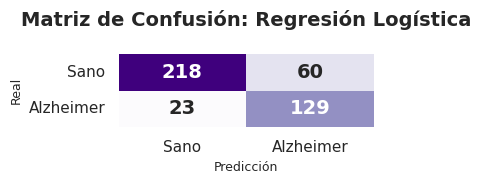


REPORTES DE CLASIFICACIÓN
              precision    recall  f1-score   support

        Sano       0.90      0.78      0.84       278
   Alzheimer       0.68      0.85      0.76       152

    accuracy                           0.81       430
   macro avg       0.79      0.82      0.80       430
weighted avg       0.83      0.81      0.81       430



In [25]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

class_names = ['Sano', 'Alzheimer']

# matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# ayuda visual
plt.figure(figsize=(4, 2))
sns.heatmap(
    cm,
    annot=True,              # Pone los números
    fmt='d',                 # Formato entero
    cmap='Purples',          # Mantenemos tu estética violeta
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False,              # Quitamos la barra lateral para un look más limpio
    annot_kws={"size": 14, "weight": "bold"} # Números más grandes y legibles
)

# personalización técnica
plt.title('Matriz de Confusión: Regresión Logística', fontsize=14, pad=20, fontweight='bold')
plt.ylabel('Real', fontsize=9)
plt.xlabel('Predicción', fontsize=9)

# ajuste fino de las etiquetas de los ejes
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# imprimir el reporte con formato
print("\n" + "="*53)
print("REPORTES DE CLASIFICACIÓN")
print("="*53)
print(classification_report(y_test, y_pred, target_names=class_names))

El modelo presenta un 0.85 de recall y un 0.68 de precisión. Es fundamental en el contexto de un modelo predictivo de diagnostico optimizar el recall por encima de la precisión de manera de reducir los falsos negativos (riego alto de perder pacientes enfermos).

### 5.5 Curva ROC (AUC)

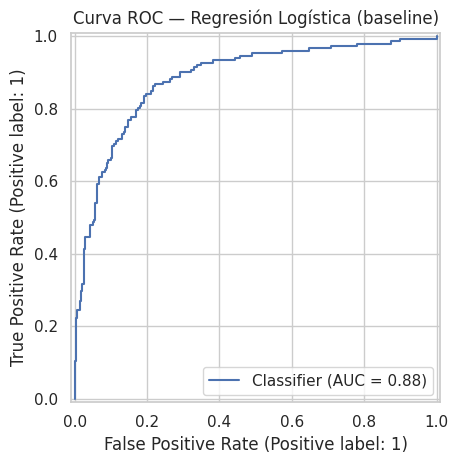

In [26]:
RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)
plt.title("Curva ROC — Regresión Logística (baseline)")
plt.tight_layout()
plt.show()

roc_auc = roc_auc_score(y_test, y_proba)
roc_auc_formatted = f"{roc_auc:.3f}"

### 5.6 Interpretación de coeficientes (Regresión Logística)

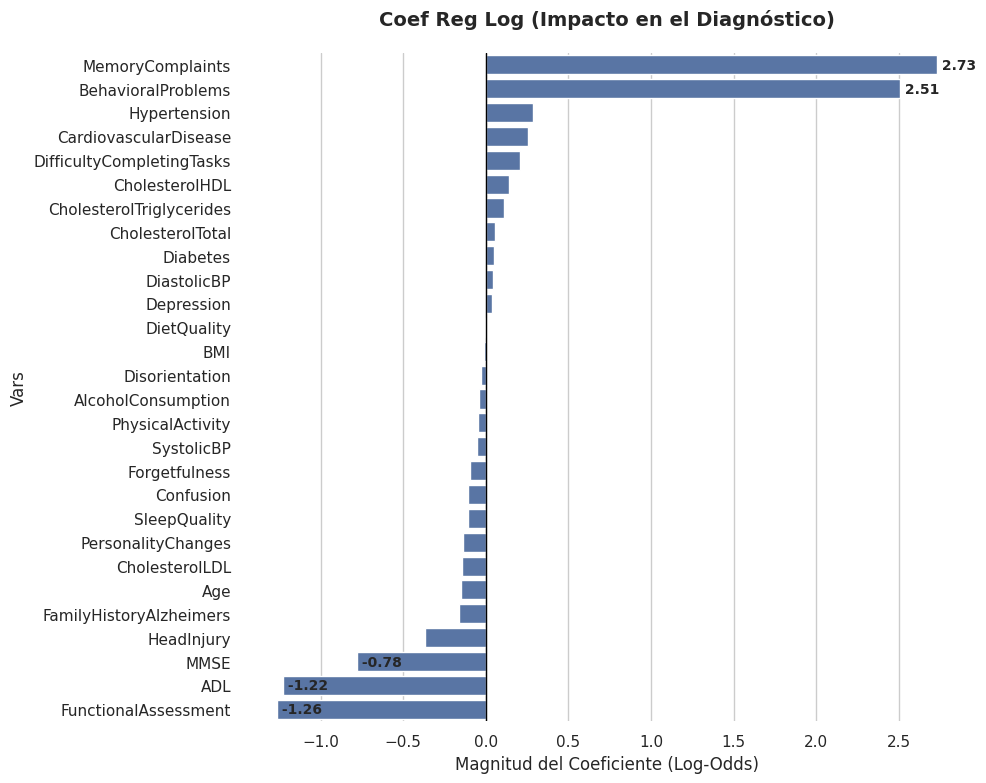

In [28]:
# Coeficientes del modelo RL
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

# Figura de barras
plt.figure(figsize=(10, 8))
sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature'
)

plt.axvline(0, color='black', linestyle='-', linewidth=1) # Línea en el cero
plt.title('Coef Reg Log (Impacto en el Diagnóstico)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Magnitud del Coeficiente (Log-Odds)', fontsize=12)
plt.ylabel('Vars', fontsize=12)

# Tags de coef values
for i, row in enumerate(coef_df.itertuples()):
    if abs(row.Coefficient) > 0.5:  # Solo los más significativos para no saturar
        plt.text(row.Coefficient, i, f' {row.Coefficient:.2f}',
                 va='center', fontsize=10, fontweight='bold')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

La regresión logística permite interpretar directamente la dirección y magnitud relativa del efecto de cada variable sobre el **log-odds** de diagnóstico de Alzheimer.

#### 5.6.1. Factores asociados a mayor riesgo (coeficientes positivos)
- **MemoryComplaints** (2.73) → el predictor más fuerte  
- **BehavioralProblems** (2.51) → muy cercano en magnitud  

Ambos inclinan fuertemente la predicción hacia Alzheimer.  
Consistente con literatura (tanto quejas subjetivas de memoria y síntomas neuropsiquiátricos suelen ser señales tempranas).

#### 5.6.2. Indicadores de preservación cognitiva/funcional (coeficientes negativos)
- **FunctionalAssessment** (−1.26)  
- **ADL** (−1.22)  
- **MMSE** (−0.78)  

Puntuaciones más altas en estas escalas reducen marcadamente la probabilidad predicha de Alzheimer (menor riesgo diagnóstico y no necesariamente causalidad protectora).

## 6. Modelo no lineal — Random Forest

Tras establecer un baseline interpretable mediante Regresión Logística, se implementa Random Forest como el siguiente paso en nuestra jerarquía de modelado. El objetivo no es simplemente maximizar métricas de rendimiento, sino realizar un diagnóstico técnico de la estructura del dataset:

-  **Detección de Interacciones Complejas**: Capturar interacciones de alto orden (por ejemplo: ¿cómo afecta la Edad al riesgo si el MMSE ya está en niveles críticos?).

- **Robustez ante No-Linealidad**: Dado que en el análisis exploratorio (EDA) observamos una independencia estadística inusual entre predictores ($r < 0.05$), este modelo nos permitirá verificar si existe una señal predictiva latente que solo emerge mediante reglas de decisión no lineales.

- **Balance entre Poder y Explicabilidad**: Random Forest mantiene una excelente capacidad de generalización y nos ofrece herramientas de Feature Importance, fundamentales para validar si la jerarquía de importancia clínica (MemoryComplaints vs. Métricas Funcionales) se mantiene bajo un paradigma no lineal.


Pregunta Clave del Proyecto: **¿Existe una ganancia predictiva significativa al permitir que el modelo aprenda patrones no aditivos entre los factores clínicos, cognitivos y de estilo de vida?**

### 6.1 Preparación de datos y modelo

- No se requiere escalado de variables.

- Se utilizan las mismas features seleccionadas

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

Justificación de hiperparametros

**n_estimators**=300: suficiente para estabilizar importancias.

**min_samples_leaf**=5: reduce sobreajuste en nodos pequeños.

**class_weight**="balanced": compensa el desbalance moderado del target.

**random_state**: garantiza reproducibilidad.

### 6.2 Entrenamiento del modelo

In [30]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Fiteo del modelo
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

### 6.3 Evaluación del modelo

In [31]:
# Predicción y Probabilidades
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC curve
roc_auc = roc_auc_score(y_test, y_proba_rf)
pr_auc = average_precision_score(y_test, y_proba_rf)

print("="*60)
print(f"{'MÉTRICAS DE DESEMPEÑO: RANDOM FOREST':^60}")
print("="*60)

# Reporte de Clasificación con nombres de clase
print(classification_report(y_test, y_pred_rf, target_names=['Sano', 'Alzheimer']))

print("-"*60)
print(f"{'Métricas de Área bajo la Curva (AUC)':^60}")
print("-"*60)
print(f"ROC AUC Score: {roc_auc:>34.4f}")
print(f"PR AUC Score (Average Precision): {pr_auc:>20.4f}")
print("="*60)

            MÉTRICAS DE DESEMPEÑO: RANDOM FOREST            
              precision    recall  f1-score   support

        Sano       0.95      0.97      0.96       278
   Alzheimer       0.95      0.91      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430

------------------------------------------------------------
            Métricas de Área bajo la Curva (AUC)            
------------------------------------------------------------
ROC AUC Score:                             0.9421
PR AUC Score (Average Precision):               0.9205


### 6.4 Importancia de los Features en el modelo de Random Forest

/tmp/ipython-input-1687292426.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


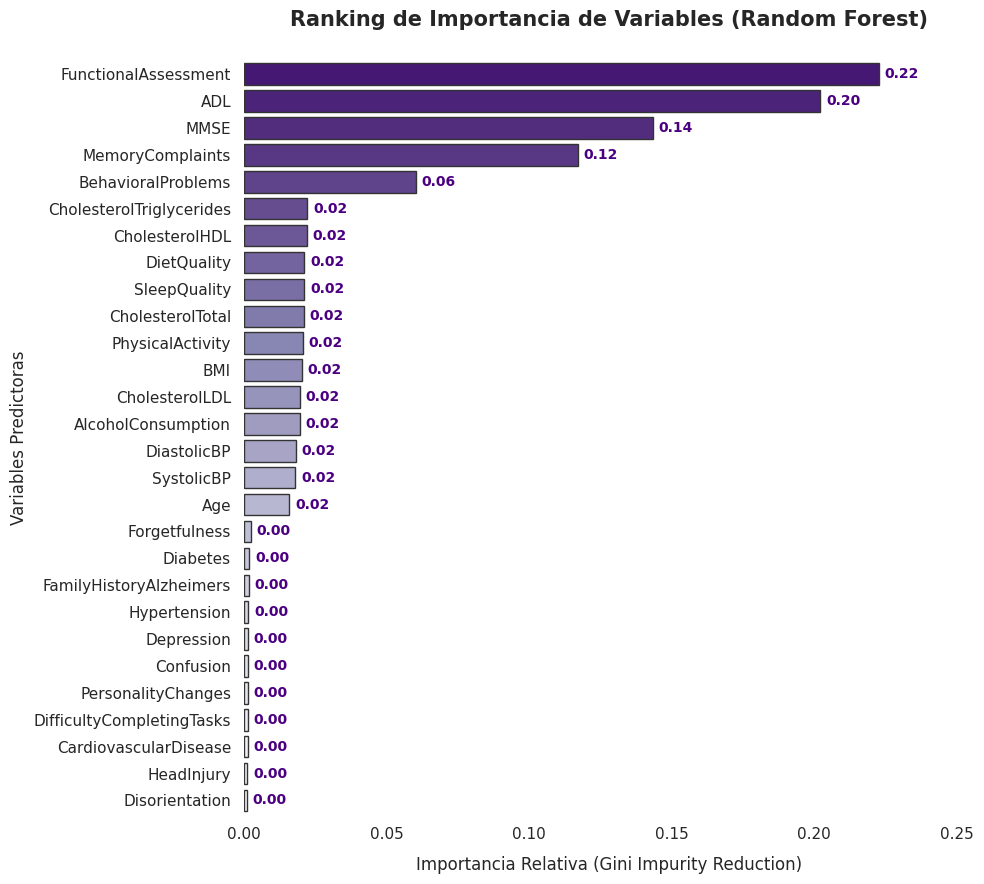

In [32]:
# Ordenar las importancias
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 9))
sns.set_theme(style="white")

ax = sns.barplot(
    data=importances,
    x='Importance',
    y='Feature',
    palette='Purples_r',
    edgecolor=".2"
)

# Valores en las barras
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.002,      # Posición X (un poco a la derecha del final de la barra)
        p.get_y() + p.get_height() / 2, # Posición Y (centrado en la barra)
        f'{width:.2f}',     # Formato con 2 decimales
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#4B0082'     # Color índigo para que resalte
    )

plt.title('Ranking de Importancia de Variables (Random Forest)', fontsize=15, fontweight='bold', pad=25)
plt.xlabel('Importancia Relativa (Gini Impurity Reduction)', fontsize=12, labelpad=10)
plt.ylabel('Variables Predictoras', fontsize=12)

# Ajustar límites para que los números no se corten
plt.xlim(0, importances['Importance'].max() * 1.15)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

### 6.5 Interpretación resultados Random Forest

En esta etapa, el análisis no se centra únicamente en la mejora de las métricas predictivas, sino en la coherencia clínica del modelo y en la consistencia de los patrones aprendidos respecto al baseline lineal.

Dominio de métricas funcionales y cognitivas
Las variables funcionales y cognitivas continúan ocupando las primeras posiciones en el ranking de importancia del Random Forest:

- FunctionalAssessment (≈ 0.22)

- ADL (≈ 0.20)

- MMSE (≈ 0.14)

Este resultado refuerza la idea de que el grado de deterioro funcional y cognitivo es el principal determinante del diagnóstico, coherente con la práctica clínica y con lo observado en la Regresión Logística.

Persistencia de variables sintomáticas relevantes
Las variables:

- MemoryComplaints (≈ 0.12)

- BehavioralProblems (≈ 0.06)

mantienen un peso no despreciable en el modelo, actuando como señales clínicas complementarias, especialmente útiles en contextos de screening o evaluación inicial.

Relegación de variables ruidosas
El resto de las variables, incluyendo síntomas inespecíficos como Confusion o Disorientation, presentan importancias ≤ 0.02. Esto indica que el modelo no lineal aprende a ignorarlas de forma natural, confirmando su bajo valor predictivo observado durante el EDA.

## 7. Interpretabilidad — SHAP values

### 7.1 Motivación

Aunque el Random Forest mejora el desempeño predictivo, su naturaleza no lineal dificulta la interpretación directa. En un contexto *Healthcare*, no alcanza con predecir mejor: es necesario explicar por qué el modelo toma determinadas decisiones.

SHAP (SHapley Additive exPlanations) permite:

- Interpretabilidad global: qué variables impulsan el modelo en promedio.

- Interpretabilidad local: cómo contribuye cada variable a la predicción de un paciente individual.

- Comparabilidad clínica con el baseline lineal (RL).

### 7.2 Cálculo de valores SHAP

Se utiliza **TreeExplainer**, adecuado para modelos basados en árboles.

In [37]:
import shap

explainer = shap.TreeExplainer(rf_model)
#Calcular valores SHAP (usamos check_additivity=False por si hay pequeñas discrepancias de punto flotante)
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Diagnóstico = 1
shap_values_positive = shap_values[1]

### 7.3 Explicabilidad: Analisis SHAP

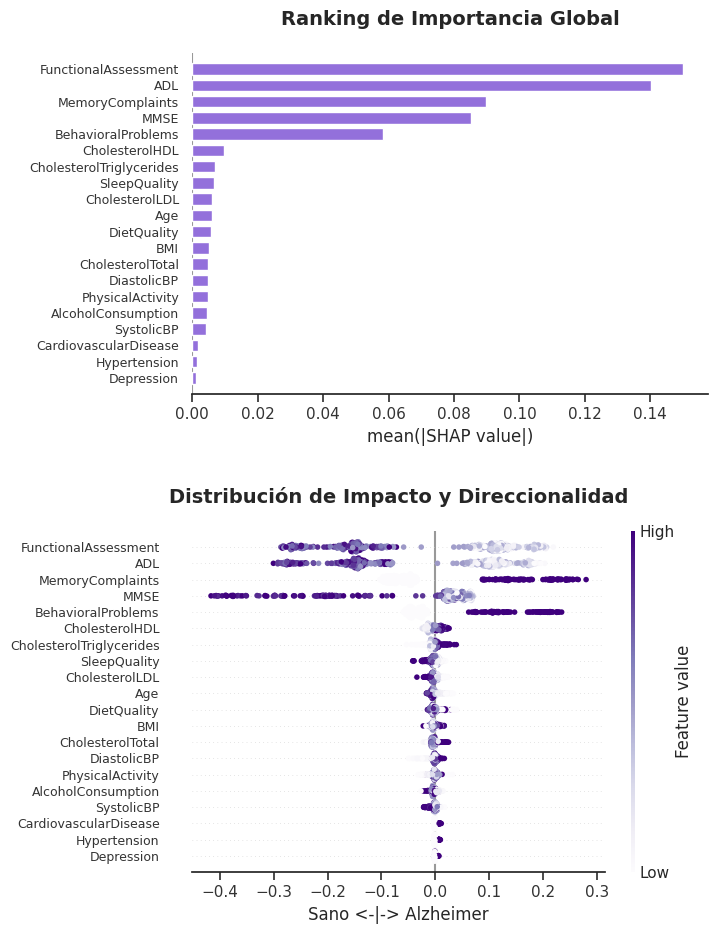

In [52]:
import numpy as np

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 18))

# SHAP BAR PLOT
plt.sca(ax1)
shap.summary_plot(
    shap_values_to_plot,
    X_test,
    plot_type="bar",
    color='#9370DB',
    show=False
)

ax1.tick_params(axis='y', labelsize=9)
ax1.set_title("Ranking de Importancia Global", fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel("mean(|SHAP value|)", fontsize=12)

# SHAP BEE SWARM
plt.sca(ax2)
shap.summary_plot(
    shap_values_to_plot,
    X_test,
    show=False,
    cmap='Purples'
)

ax2.tick_params(axis='y', labelsize=9)
ax2.set_title("Distribución de Impacto y Direccionalidad", fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel("Sano <-|-> Alzheimer", fontsize=12)

plt.subplots_adjust(hspace=0.4)
plt.show()

El análisis SHAP muestra que:

- **Dominancia funcional**:
FunctionalAssessment y ADL emergen como las variables más influyentes del modelo. Esto confirma que la pérdida de autonomía funcional es el rasgo más distintivo para la clasificación en este dataset.

- **Componente cognitivo y conductual**:
MemoryComplaints, MMSE y BehavioralProblems conforman un segundo bloque de importancia. Estas variables reflejan dominios clásicos del deterioro cognitivo y conductual, alineándose con la práctica clínica y con los resultados del baseline lineal.

- **Baja relevancia periférica**
Variables relacionadas con perfil lipídico, dieta, actividad física o antecedentes médicos generales muestran un impacto marginal en el modelo. Si bien estos factores pueden ser relevantes a nivel epidemiológico o de riesgo a largo plazo, no resultan determinantes para la clasificación directa en este contexto.

Respecto del impacto y la dirección:

- Observamos un **efecto protector** en MMSE, ADL y FA, donde valores altos se desplazan hacia la izquierda (valores SHAP negativos). Esto indica que un alto desempeño en estas áreas reduce significativamente el riesgo de Alzheimer.

- En cambio, MemoryComplaints y BehavioralProblems, la presencia del síntoma (valores altos) desplaza los puntos hacia la derecha, aumentando la probabilidad del diagnóstico positivo. Esto lo podemos considerar como **efecto de Riesgo**.

## 8. Conclusiones finales y aprendizajes del proyecto

### 8.1 Enfoque metodológico

Este proyecto presenta un flujo completo de **Machine Learning aplicado a Healthcare, con foco en clasificación predictiva interpretable para apoyar la priorización clínica de pacientes con riesgo de Alzheimer**.
A lo largo del análisis se priorizó:

- Claridad conceptual y trazabilidad clínica.
- Decisiones metodológicas justificadas.
- Reproducibilidad y buenas prácticas de modelado.

El EDA orientado a clínica permitió identificar variables con señal real y distinguirlas de aquellas potencialmente ruidosas, evitando ingeniería artificial o selección prematura.

### 8.2 Resultados clave y validación clínica

La comparación entre un baseline interpretable (Regresión Logística) y un modelo no lineal (Random Forest) mostró que:

- El **Random Forest** mejora métricas relevantes (recall y precision), evidenciando la presencia de relaciones no lineales.

- Ambos modelos coinciden en la jerarquía clínica de predictores.

- Las **variables funcionales y cognitivas** (FunctionalAssessment, ADL, MMSE) dominan la señal predictiva, mientras que síntomas inespecíficos y antecedentes generales aportan información marginal.

- El análisis de explicabilidad con **SHAP** confirmó que el modelo toma decisiones coherentes con el conocimiento clínico, reforzando su rol como herramienta de apoyo a la decisión.

### 8.3 Motivación personal y valor profesional del proyecto

Desarrollé este proyecto con el objetivo de consolidar y demostrar **competencias clave como científico de datos**, aplicando Machine Learning a un problema realista del dominio *Healthcare*. El foco estuvo puesto en construir modelos útiles, interpretables y metodológicamente sólidos, más que en maximizar métricas de forma artificial.

A lo largo del trabajo implementé un flujo profesional completo:
- EDA orientado a la pregunta clínica, definición de baselines interpretables (RL), comparación con modelos no lineales (RF) y validación mediante técnicas de explicabilidad (SHAP).
Este proyecto refleja habilidades centrales en ciencia de datos aplicada, incluyendo modelado supervisado, evaluación con métricas adecuadas, interpretación de modelos y comunicación técnica clara.

Mi objetivo es continuar desarrollándome como **Data Scientist**, participando en proyectos donde el rigor analítico, el contexto del problema y la toma de decisiones basada en datos sean fundamentales.

## 9. Apéndice

#### 9.1 Referencia del dataset

El dataset utilizado en este proyecto fue obtenido de Kaggle y debe ser citado de la siguiente manera:

Rabie El Kharoua (2024). Alzheimer's Disease Dataset.
Kaggle.
https://doi.org/10.34740/KAGGLE/DSV/8668279

#### 9.2 Consideraciones éticas y de uso de datos

El dataset es de acceso público y fue utilizado exclusivamente con fines educativos y demostrativos.

**No contiene información identificable de pacientes.**

El modelo desarrollado **no está destinado a uso clínico real**, diagnóstico ni toma de decisiones médicas directas.

El análisis se enmarca como ejercicio metodológico de **Machine Learning aplicado a salud**.

#### 9.3 Reproducibilidad

- Se fijaron semillas aleatorias para asegurar resultados reproducibles.

- El pipeline completo (EDA, preparación de datos, modelado y evaluación) se ejecuta de forma secuencial en un único notebook.

- Las librerías utilizadas pertenecen al ecosistema estándar de Python para ciencia de datos (pandas, numpy, scikit-learn, shap, matplotlib).

#### 9.4 Alcance del proyecto

Este notebook forma parte de un portfolio personal de proyectos en ciencia de datos, orientado a demostrar:

Capacidad analítica.

Criterio metodológico.

Comunicación técnica clara.

Aplicación responsable de Machine Learning en contextos de *Healthcare* y *Life Science*